<a href="https://colab.research.google.com/github/rymarinelli/Advanced-Programming-/blob/main/LLM_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Create the directory to extract the contents
!mkdir -p /content/data

# Download the file from Google Drive using wget and save it as sql.zip
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1b77j33x5bJkUMzekbpdtXZqusXCRj-WX' -O /content/sql.zip

# Extract the contents of the zip file into the 'data' directory
!unzip /content/sql.zip -d /content/data


--2024-11-22 08:31:46--  https://docs.google.com/uc?export=download&id=1b77j33x5bJkUMzekbpdtXZqusXCRj-WX
Resolving docs.google.com (docs.google.com)... 142.251.12.138, 142.251.12.139, 142.251.12.101, ...
Connecting to docs.google.com (docs.google.com)|142.251.12.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1b77j33x5bJkUMzekbpdtXZqusXCRj-WX&export=download [following]
--2024-11-22 08:31:46--  https://drive.usercontent.google.com/download?id=1b77j33x5bJkUMzekbpdtXZqusXCRj-WX&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.68.132, 2404:6800:4003:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.68.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 435651 (425K) [application/octet-stream]
Saving to: ‘/content/sql.zip’

/content/sql.zip    100%[===================>] 425.44K  --.-KB/s    in

In [ ]:
import pandas as pd

df = pd.read_csv("/content/data/Modified_SQL_Dataset.csv")

# SQL Injection and non-SQL Injection examples (Balanced dataset: 5 SQL, 5 non-SQL)
sql_examples = df[df['Label'] == 1]["Query"].to_list()

non_sql_examples = df[df['Label'] == 0]["Query"].to_list()

In [ ]:
import torch
import numpy as np
from transformers import GPTNeoForCausalLM, AutoTokenizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Set device to CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load GPT-Neo model and tokenizer for SQL Injection feature extraction
model_neo = GPTNeoForCausalLM.from_pretrained("EleutherAI/gpt-neo-1.3B", output_hidden_states=True).to(device)
tokenizer_neo = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-1.3B")

# Function to extract activations from all layers of GPT-Neo for a given sentence
def get_activations_for_sentence(sentence, model, tokenizer):
    input_ids = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=2048).input_ids.to(device)
    activations = {}

    def get_activation(name):
        def hook(model, input, output):
            if isinstance(output, tuple):
                output = output[0]
            activations[name] = output.detach().cpu().numpy()
        return hook

    hooks = []
    num_layers = len(model.transformer.h)  # Number of layers in the model
    for layer in range(num_layers):
        layer_name = f'layer_{layer}'
        hook_handle = model.transformer.h[layer].register_forward_hook(get_activation(layer_name))
        hooks.append(hook_handle)

    with torch.no_grad():
        _ = model(input_ids)

    # Remove hooks after forward pass
    for hook_handle in hooks:
        hook_handle.remove()

    return activations


# Function to reduce dimensionality by mean pooling across neurons
def reduce_dimensionality(activations):
    reduced_activations = []
    for layer in activations.values():
        mean_activation = np.mean(layer, axis=-1)  # Mean pooling across neurons
        reduced_activations.append(mean_activation.flatten())
    return np.concatenate(reduced_activations)

# Extract activations for SQL and non-SQL examples from GPT-Neo
def extract_activations_for_examples(model, tokenizer, examples):
    all_activations = []
    for example in examples:
        activations = get_activations_for_sentence(example, model, tokenizer)
        reduced_activations = reduce_dimensionality(activations)
        all_activations.append(reduced_activations)
    return all_activations

# Get activations for SQL and non-SQL examples
activations_neo_sql = extract_activations_for_examples(model_neo, tokenizer_neo, sql_examples)
activations_neo_non_sql = extract_activations_for_examples(model_neo, tokenizer_neo, non_sql_examples)

# Find the maximum activation size across all examples
max_len = max([len(a) for a in activations_neo_sql + activations_neo_non_sql])

# Function to pad activations to the maximum length
def pad_activations(activations, max_len):
    return np.array([np.pad(a, (0, max_len - len(a)), 'constant') for a in activations])

# Pad all activations to the same size
activations_neo_sql = pad_activations(activations_neo_sql, max_len)
activations_neo_non_sql = pad_activations(activations_neo_non_sql, max_len)

# Combine SQL and non-SQL activations
all_activations_neo = np.concatenate((activations_neo_sql, activations_neo_non_sql), axis=0)

# Labels for the data: 1 for SQL Injection, 0 for non-SQL examples
labels = np.array([1] * len(activations_neo_sql) + [0] * len(activations_neo_non_sql))

# Apply PCA to reduce the activations to 2 dimensions for visualization
pca = PCA(n_components=2)
activations_pca = pca.fit_transform(all_activations_neo)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.31G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:774: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

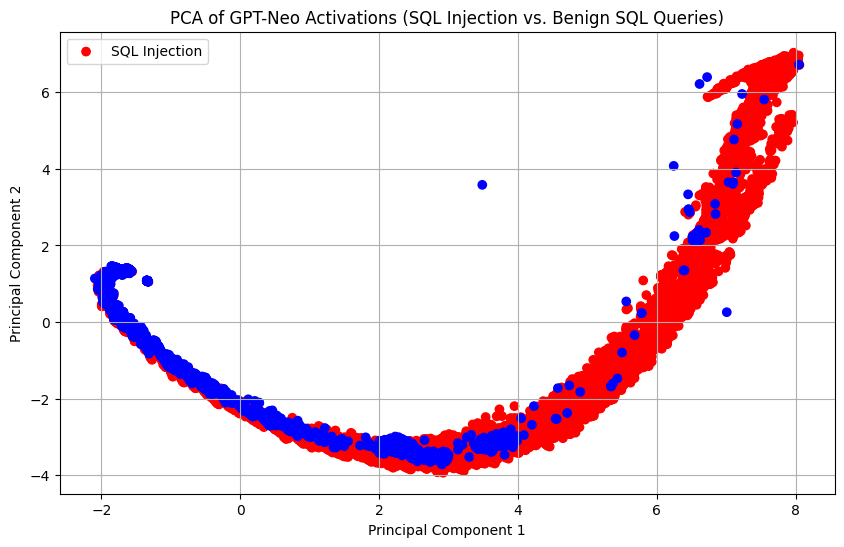

In [ ]:
# Visualize the clustering of activations
plt.figure(figsize=(10, 6))
colors = ['red' if label == 1 else 'blue' for label in labels]
plt.scatter(activations_pca[:, 0], activations_pca[:, 1], c=colors, label=labels)
plt.title("PCA of GPT-Neo Activations (SQL Injection vs. Benign SQL Queries)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(["SQL Injection", "Non-SQL"])
plt.grid(True)
plt.show()


In [ ]:
torch.cuda.empty_cache()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPTNeoForCausalLM, AutoTokenizer

# Set device to CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load GPT-Neo model and tokenizer
model_neo = GPTNeoForCausalLM.from_pretrained("EleutherAI/gpt-neo-2.7B", output_hidden_states=True).to(device)
tokenizer_neo = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-2.7B")

# Input text (SQL Injection example)
#input_text = "SELECT * FROM users WHERE username = 'admin' --"

# Tokenize the input
input_ids = tokenizer_neo(input_text, return_tensors="pt").input_ids.to(device)

# Dictionary to store activations from multiple layers
activations = {}

# Define hook function to capture activations from each layer
def get_activation(name):
    def hook(model, input, output):
        if isinstance(output, tuple):
            output = output[0]
        activations[name] = output.detach().cpu().numpy()  # Convert to NumPy
    return hook

# Register hooks for all layers
hooks = []
num_layers = len(model_neo.transformer.h)
for i in range(num_layers):
    hook_handle = model_neo.transformer.h[i].register_forward_hook(get_activation(f'layer_{i+1}'))
    hooks.append(hook_handle)

# Forward pass
with torch.no_grad():
    output = model_neo(input_ids)

# Remove hooks after the forward pass
for hook_handle in hooks:
    hook_handle.remove()

# Extract maximum activations for each layer
max_activations = []
for layer_name, activation in activations.items():
    max_activation_value = np.max(activation)  # Get the maximum value in the activation
    max_activations.append(max_activation_value)

# Plot the maximum activations for each layer
plt.figure(figsize=(10, 6))
layers = [f'layer_{i+1}' for i in range(num_layers)]
plt.plot(layers, max_activations, marker='o', color='b')
plt.title("Maximum Activations for SQL Injection Across GPT-Neo Layers")
plt.xlabel("Layer")
plt.ylabel("Maximum Activation Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:774: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

NameError: name 'input_text' is not defined

In [ ]:
import torch
import numpy as np
from transformers import GPT2LMHeadModel, AutoTokenizer
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Set device to CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load GPT-2 XL model and tokenizer
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2-xl", output_hidden_states=True).to(device)
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2-xl")

# Ensure pad_token is defined
tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token

# Function to extract activations from GPT-2 for a given sentence
def get_gpt2_activations_for_sentence(sentence, model, tokenizer, max_len):
    input_ids = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=max_len
    ).input_ids.to(device)

    activations = {}

    def get_activation(name):
        def hook(module, input, output):
            if isinstance(output, tuple):
                output = output[0]
            activations[name] = output.detach().cpu().numpy()
        return hook

    hooks = []
    for layer in range(len(model.transformer.h)):
        layer_name = f'layer_{layer}'
        hook_handle = model.transformer.h[layer].register_forward_hook(get_activation(layer_name))
        hooks.append(hook_handle)

    with torch.no_grad():
        _ = model(input_ids)

    for hook_handle in hooks:
        hook_handle.remove()

    return activations

# Function to extract and reduce activations for multiple examples
def extract_gpt2_activations_for_examples(model, tokenizer, examples, max_len):
    all_activations = []
    for example in examples:
        activations = get_gpt2_activations_for_sentence(example, model, tokenizer, max_len)
        reduced_activations = reduce_dimensionality(activations)  # Assume this function is defined
        all_activations.append(reduced_activations)
    return all_activations

# Safe padding function
def pad_activations(activations, max_len):
    padded_activations = []
    for activation in activations:
        if len(activation) > max_len:
            activation = activation[:max_len]  # Truncate if longer than max_len
        padded_activation = np.pad(activation, (0, max(0, max_len - len(activation))), 'constant')
        padded_activations.append(padded_activation)
    return np.array(padded_activations)

# Example SQL and non-SQL queries
#sql_examples = ["SELECT * FROM users WHERE id = 1;", "DROP TABLE users;"]  # Replace with real data
#non_sql_examples = ["Show me the user data.", "What is the status of my account?"]  # Replace with real data

# Define max sequence length
max_len = 1024  # GPT-2 XL limit

# Extract GPT-2 activations
activations_gpt2_sql = extract_gpt2_activations_for_examples(model_gpt2, tokenizer_gpt2, sql_examples, max_len)
activations_gpt2_non_sql = extract_gpt2_activations_for_examples(model_gpt2, tokenizer_gpt2, non_sql_examples, max_len)

# Calculate the actual max activation length
max_activation_len = max([len(a) for a in activations_gpt2_sql + activations_gpt2_non_sql])

# Pad activations
activations_gpt2_sql = pad_activations(activations_gpt2_sql, max_activation_len)
activations_gpt2_non_sql = pad_activations(activations_gpt2_non_sql, max_activation_len)

# Combine activations
all_activations_gpt2 = np.concatenate((activations_gpt2_sql, activations_gpt2_non_sql), axis=0)

# Apply PCA transformation (assuming PCA is already defined and trained on GPT-Neo activations)
gpt2_activations_pca = pca.transform(all_activations_gpt2)

# Labels for SQL Injection (1) and non-SQL (0)
labels_gpt2 = np.array([1] * len(activations_gpt2_sql) + [0] * len(activations_gpt2_non_sql))

# Train kNN classifier on GPT-Neo PCA transformed data (assuming `activations_pca` and `labels` are from GPT-Neo)
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(activations_pca, labels)

# Predict labels for GPT-2 activations
gpt2_predictions = knn_classifier.predict(gpt2_activations_pca)

# Visualize results
plt.figure(figsize=(10, 6))
colors_gpt2 = ['red' if label == 1 else 'blue' for label in gpt2_predictions]
plt.scatter(gpt2_activations_pca[:, 0], gpt2_activations_pca[:, 1], c=colors_gpt2)
plt.title("GPT-2 Activations in GPT-Neo PCA Space (SQL Injection vs. Non-SQL)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(["SQL Injection", "Benign SQL Queries"])
plt.grid(True)
plt.show()


In [ ]:
from transformers import GPT2LMHeadModel, AutoTokenizer
from sklearn.neighbors import KNeighborsClassifier
import torch
import numpy as np

# Load GPT-2 model and tokenizer for SQL Injection feature extraction
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2", output_hidden_states=True).to(device)
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")

# Function to extract activations from GPT-2 for a given sentence
def get_gpt2_activations_for_sentence(sentence, model, tokenizer):
    # Truncate input to max 1024 tokens, which is GPT-2's limit
    input_ids = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(device)
    activations = {}

    def get_activation(name):
        def hook(model, input, output):
            if isinstance(output, tuple):
                output = output[0]
            activations[name] = output.detach().cpu().numpy()
        return hook

    hooks = []
    num_layers = len(model.transformer.h)  # Number of layers in GPT-2 model
    for layer in range(num_layers):
        layer_name = f'layer_{layer}'
        hook_handle = model.transformer.h[layer].register_forward_hook(get_activation(layer_name))
        hooks.append(hook_handle)

    with torch.no_grad():
        _ = model(input_ids)

    # Remove hooks after forward pass
    for hook_handle in hooks:
        hook_handle.remove()

    return activations

# Extract activations for GPT-2 examples
def extract_gpt2_activations_for_examples(model, tokenizer, examples):
    all_activations = []
    for example in examples:
        activations = get_gpt2_activations_for_sentence(example, model, tokenizer)
        reduced_activations = reduce_dimensionality(activations)  # Assume you already have this function defined
        all_activations.append(reduced_activations)
    return all_activations

# Get activations for SQL and non-SQL examples using GPT-2
activations_gpt2_sql = extract_gpt2_activations_for_examples(model_gpt2, tokenizer_gpt2, sql_examples)
activations_gpt2_non_sql = extract_gpt2_activations_for_examples(model_gpt2, tokenizer_gpt2, non_sql_examples)

# Pad all GPT-2 activations to the same size as GPT-Neo activations
activations_gpt2_sql = pad_activations(activations_gpt2_sql, max_len)  # Assume pad_activations function is defined
activations_gpt2_non_sql = pad_activations(activations_gpt2_non_sql, max_len)

# Combine SQL and non-SQL activations for GPT-2
all_activations_gpt2 = np.concatenate((activations_gpt2_sql, activations_gpt2_non_sql), axis=0)

# Apply Neo's PCA transformation on GPT-2 activations
gpt2_activations_pca = pca.transform(all_activations_gpt2)

# Labels for the GPT-2 data: 1 for SQL Injection, 0 for non-SQL examples
labels_gpt2 = np.array([1] * len(activations_gpt2_sql) + [0] * len(activations_gpt2_non_sql))

# Train a classifier (k-Nearest Neighbors) using GPT-Neo's PCA transformed data
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(activations_pca, labels)

# Predict labels for GPT-2 activations using the classifier trained on Neo's PCA space
gpt2_predictions = knn_classifier.predict(gpt2_activations_pca)

# Visualize the classification results
plt.figure(figsize=(10, 6))
colors_gpt2 = ['red' if label == 1 else 'blue' for label in gpt2_predictions]
plt.scatter(gpt2_activations_pca[:, 0], gpt2_activations_pca[:, 1], c=colors_gpt2)
plt.title("GPT-2 Activations in GPT-Neo PCA Space (SQL Injection vs. Non-SQL)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(["SQL Injection", "Benign SQL Queries"])
plt.grid(True)
plt.show()


In [ ]:
# Visualize the classification results
plt.figure(figsize=(10, 6))

# Assign red for SQL Injection (label == 1) and blue for non-SQL (label == 0)
colors_gpt2 = ['red' if label == 1 else 'blue' for label in gpt2_predictions]

plt.scatter(gpt2_activations_pca[:, 0], gpt2_activations_pca[:, 1], c=colors_gpt2)
plt.title("GPT-2 Activations in GPT-Neo PCA Space (SQL Injection vs. Non-SQL)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Update the legend to reflect the colors correctly
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='PredictedSQL Injection'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=' Predicted Benign SQL Queries')])

plt.grid(True)
plt.show()


In [ ]:
from transformers import GPT2LMHeadModel, AutoTokenizer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load GPT-2 model and tokenizer for SQL Injection feature extraction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2", output_hidden_states=True).to(device)
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")

# Function to extract activations using causal tracing for GPT-2
def get_gpt2_activations_for_sentence(sentence, model, tokenizer):
    input_ids = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(device)
    activations = {}

    def get_activation(name):
        def hook(model, input, output):
            if isinstance(output, tuple):
                output = output[0]
            activations[name] = output.detach().cpu().numpy()
        return hook

    hooks = []
    num_layers = len(model.transformer.h)  # Number of layers in GPT-2 model
    for layer in range(num_layers):
        layer_name = f'layer_{layer}'
        hook_handle = model.transformer.h[layer].register_forward_hook(get_activation(layer_name))
        hooks.append(hook_handle)

    with torch.no_grad():
        _ = model(input_ids)

    # Remove hooks after forward pass
    for hook_handle in hooks:
        hook_handle.remove()

    return activations

# Function to pad activations to the same length
def pad_activations(activations, target_len):
    return np.array([np.pad(a, (0, target_len - len(a)), 'constant') for a in activations])

# Function to extract and reduce activations for a list of examples using GPT-2
def extract_gpt2_activations_for_examples(model, tokenizer, examples):
    all_activations = []
    for example in examples:
        activations = get_gpt2_activations_for_sentence(example, model, tokenizer)
        reduced_activations = reduce_dimensionality(activations)  # Assume this function reduces activations
        all_activations.append(reduced_activations)
    return all_activations

# Assuming sql_examples and non_sql_examples are your input data
# Extract activations for SQL and non-SQL examples using GPT-2
activations_gpt2_sql = extract_gpt2_activations_for_examples(model_gpt2, tokenizer_gpt2, sql_examples)
activations_gpt2_non_sql = extract_gpt2_activations_for_examples(model_gpt2, tokenizer_gpt2, non_sql_examples)

# Find the maximum length of activations
max_len = max([len(a) for a in activations_gpt2_sql + activations_gpt2_non_sql])

# Pad the activations to ensure consistent length
activations_gpt2_sql = pad_activations(activations_gpt2_sql, max_len)
activations_gpt2_non_sql = pad_activations(activations_gpt2_non_sql, max_len)

#  Combine SQL and non-SQL activations for GPT-2
all_activations_gpt2 = np.concatenate((activations_gpt2_sql, activations_gpt2_non_sql), axis=0)

# Apply PCA on GPT-2 activations
pca_gpt2 = PCA(n_components=2)  # Use 2 components for visualization
gpt2_activations_pca = pca_gpt2.fit_transform(all_activations_gpt2)

# Use the kNN classifier trained on GPT-Neo's PCA space to predict labels for GPT-2 activations
gpt2_predictions = knn_classifier.predict(gpt2_activations_pca)

# accuracy by comparing the predicted labels with true labels
labels_gpt2 = np.array([1] * len(activations_gpt2_sql) + [0] * len(activations_gpt2_non_sql))
accuracy = accuracy_score(labels_gpt2, gpt2_predictions)


print(f"Accuracy of kNN classifier (trained on GPT-Neo PCA) applied to GPT-2 activations: {accuracy:.2f}")




In [ ]:
# Visualize the classification results
plt.figure(figsize=(10, 6))
colors_gpt2 = ['red' if label == 1 else 'blue' for label in gpt2_predictions]
plt.scatter(gpt2_activations_pca[:, 0], gpt2_activations_pca[:, 1], c=colors_gpt2)
plt.title("GPT-2 Activations Classifed By GPT-Neo Classifier")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='SQL Injection'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Benign SQL Queries')])
plt.grid(True)
plt.show()